### Visualize corn and soy vegetation regime curves

[INFO] Computing NDVI samples and stats from rasters…

[INFO] Year 2013
    May NDVI range (valid pixels): -0.200 to 1.000
    May — Corn: n=184823865, sampled=80000
    May — Soy : n=149574745, sampled=80000
   June NDVI range (valid pixels): -0.200 to 1.000
   June — Corn: n=202498999, sampled=80000
   June — Soy : n=166854535, sampled=80000
   July NDVI range (valid pixels): -0.200 to 1.000
   July — Corn: n=194676311, sampled=80000
   July — Soy : n=157859082, sampled=80000
    Aug NDVI range (valid pixels): -0.200 to 1.000
    Aug — Corn: n=195362905, sampled=80000
    Aug — Soy : n=158456972, sampled=80000
   Sept NDVI range (valid pixels): -0.200 to 1.000
   Sept — Corn: n=191639805, sampled=80000
   Sept — Soy : n=156981030, sampled=80000

[INFO] Year 2018
    May NDVI range (valid pixels): -0.200 to 1.000
    May — Corn: n=203202991, sampled=80000
    May — Soy : n=178280875, sampled=80000
   June NDVI range (valid pixels): -0.200 to 1.000
   June — Corn: n=181434467, sampled=

/var/folders/19/_g41qrw96534nhy04lv27fmh0000gq/T/ipykernel_74244/4284200960.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/19/_g41qrw96534nhy04lv27fmh0000gq/T/ipykernel_74244/4284200960.py:106: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


[OK] Wrote figure → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure_corn_soy_NDVI_regime_pooled_2013_2018_2021.png
[OK] Wrote figure → /Volumes/Conowingo/NASA_UMRB_Legacy_Wetlands/Figures/Figure_corn_soy_NDVI_regime_pooled_2013_2018_2021.jpg


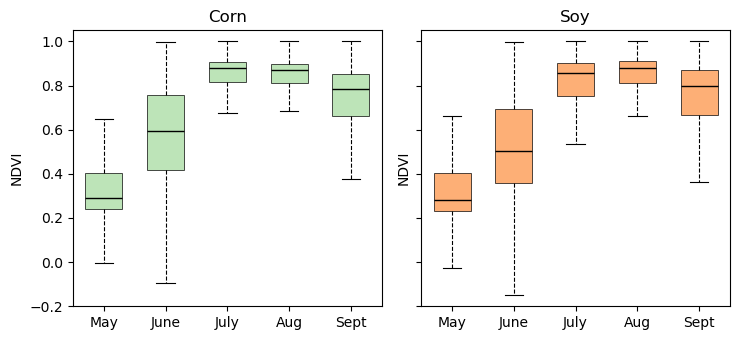

In [9]:
#!/usr/bin/env python3
# corn_soy_ndvi_regime_pooled_years.py
# Monthly NDVI regime curves (boxplots) for corn and soy,
# pooled across selected years (e.g., 2013, 2018, 2021).

from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import os

# ---------------- USER SETTINGS ----------------
ROOT = Path(os.environ.get("DML_NDVI_DATA_ROOT", "./ndvi_wetlands_data"))

YEARS = [2013, 2018, 2021]
MONTHS = ["05", "06", "07", "08", "09"]
MONTH_LABELS = {"05": "May", "06": "June", "07": "July", "08": "Aug", "09": "Sept"}

# Limit number of pixels per crop-month-year (None = use all)
SAMPLE_MAX = 80_000

# Outputs
OUT_DIR = ROOT / "Figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_FILE = OUT_DIR / "NDVI_corn_soy_samples_2013_2018_2021.csv.gz"
STATS_FILE  = OUT_DIR / "NDVI_corn_soy_stats_2013_2018_2021.csv"
OUT_FIG     = OUT_DIR / "Figure_corn_soy_NDVI_regime_pooled_2013_2018_2021.png"

# Set to True ONLY if you want to force recomputation from rasters.
RECALC = True
# ------------------------------------------------


def read_and_align_mask(mask_path, ref_ds):
    """Read a uint8 crop mask and align it to the reference grid."""
    with rasterio.open(mask_path) as src:
        if (
            src.crs == ref_ds.crs
            and src.transform == ref_ds.transform
            and src.width == ref_ds.width
            and src.height == ref_ds.height
        ):
            arr = src.read(1)
        else:
            arr = np.zeros((ref_ds.height, ref_ds.width), dtype=src.dtypes[0])
            reproject(
                source=rasterio.band(src, 1),
                destination=arr,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_ds.transform,
                dst_crs=ref_ds.crs,
                dst_width=ref_ds.width,
                dst_height=ref_ds.height,
                resampling=Resampling.nearest,
            )
    # Non-zero pixels are crop
    return arr != 0


def read_and_align_ndvi(ndvi_path, ref_ds):
    """Read a float NDVI mosaic and align to the reference grid."""
    with rasterio.open(ndvi_path) as src:
        if (
            src.crs == ref_ds.crs
            and src.transform == ref_ds.transform
            and src.width == ref_ds.width
            and src.height == ref_ds.height
        ):
            nd = src.read(1).astype("float32")
        else:
            nd = np.full((ref_ds.height, ref_ds.width), np.nan, dtype="float32")
            reproject(
                source=rasterio.band(src, 1),
                destination=nd,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=ref_ds.transform,
                dst_crs=ref_ds.crs,
                dst_width=ref_ds.width,
                dst_height=ref_ds.height,
                resampling=Resampling.nearest,
            )
    return nd


def series_in_order(pairs, order):
    """
    Convert list of (month_label, values_array) pairs to a list of arrays
    in the given month order, replacing missing months with NaN arrays.
    """
    lookup = {m: v for m, v in pairs}
    out = []
    for label in order:
        v = lookup.get(label)
        if v is None or v.size == 0:
            v = np.array([np.nan], dtype="float32")
        out.append(v)
    return out


def styled_boxplot(ax, data, tick_labels, facecolor, median_lw=1.0):
    """Boxplot styling with thin black borders and dashed whiskers."""
    bp = ax.boxplot(
        data,
        labels=tick_labels,   # use set_xticklabels if this errors in your MPL version
        showfliers=False,
        patch_artist=True,
        widths=0.6,
        whis=1.5,
    )

    # Box fill + borders
    for box in bp["boxes"]:
        box.set_facecolor(facecolor)
        box.set_alpha(0.7)
        box.set_edgecolor("black")
        box.set_linewidth(0.7)  # thin black border

    # Whiskers (dashed)
    for whisker in bp["whiskers"]:
        whisker.set_linewidth(0.8)
        whisker.set_color("black")
        whisker.set_linestyle("--")

    # Caps (keep solid, thin)
    for cap in bp["caps"]:
        cap.set_linewidth(0.8)
        cap.set_color("black")

    # Median lines
    for med in bp["medians"]:
        med.set_color("black")
        med.set_linewidth(median_lw)

    ax.grid(False)


def compute_samples_and_stats():
    """
    Heavy step: iterate over YEARS x MONTHS, read NDVI mosaics and crop masks,
    extract per-pixel NDVI, compute summary stats, and save sampled NDVI values.

    Results:
      - STATS_FILE: per year x crop x month summary table
      - SAMPLE_FILE: gzipped CSV with sampled NDVI values (year, crop, month, ndvi)
    """
    records_stats = []
    sample_rows = []

    print("[INFO] Computing NDVI samples and stats from rasters…")
    for year in YEARS:
        print(f"\n[INFO] Year {year}")
        monthly_max_dir = ROOT / "NDVI" / str(year)

        # Use May as reference grid for this year
        ref_path = monthly_max_dir / f"{year}_{MONTHS[0]}_MAX" / f"NDVI_{year}_{MONTHS[0]}_MAX_MOSAIC.tif"
        if not ref_path.exists():
            raise FileNotFoundError(f"Reference raster not found for {year}: {ref_path}")

        # Crop masks for this year
        crop_mask_dir = ROOT / "CropMasks" / str(year)
        corn_mask_path = crop_mask_dir / f"CDL_{year}_corn_mask_uint8.tif"
        soy_mask_path  = crop_mask_dir / f"CDL_{year}_soy_mask_uint8.tif"

        with rasterio.open(ref_path) as ref:
            corn_mask = read_and_align_mask(corn_mask_path, ref)
            soy_mask  = read_and_align_mask(soy_mask_path,  ref)

            for mo in MONTHS:
                month_label = MONTH_LABELS[mo]
                ndvi_path = monthly_max_dir / f"{year}_{mo}_MAX" / f"NDVI_{year}_{mo}_MAX_MOSAIC.tif"
                if not ndvi_path.exists():
                    print(f"  [WARN] Missing monthly mosaic: {ndvi_path}")
                    continue

                nd = read_and_align_ndvi(ndvi_path, ref)

                # Valid NDVI range (defensive)
                valid = np.isfinite(nd) & (nd >= -0.2) & (nd <= 1.0)

                if valid.any():
                    print(
                        f"  {month_label:>5} NDVI range (valid pixels): "
                        f"{np.nanmin(nd[valid]):.3f} to {np.nanmax(nd[valid]):.3f}"
                    )

                # ---------- Corn ----------
                vals_c = nd[corn_mask & valid]
                if vals_c.size:
                    # Stats use all valid pixels
                    rec_c = {
                        "year": year,
                        "crop": "Corn",
                        "month": month_label,
                        "n_pixels": int(vals_c.size),
                        "mean_ndvi": float(np.nanmean(vals_c)),
                        "median_ndvi": float(np.nanmedian(vals_c)),
                        "sd_ndvi": float(np.nanstd(vals_c)),
                    }
                    records_stats.append(rec_c)

                    # Sampling for boxplots (optional downsampling)
                    plot_c = vals_c
                    if SAMPLE_MAX and plot_c.size > SAMPLE_MAX:
                        idx = np.random.choice(plot_c.size, SAMPLE_MAX, replace=False)
                        plot_c = plot_c[idx]

                    for v in plot_c:
                        sample_rows.append(
                            {"year": year, "crop": "Corn", "month": month_label, "ndvi": float(v)}
                        )

                    print(
                        f"  {month_label:>5} — Corn: n={rec_c['n_pixels']}, "
                        f"sampled={plot_c.size}"
                    )

                # ---------- Soy ----------
                vals_s = nd[soy_mask & valid]
                if vals_s.size:
                    rec_s = {
                        "year": year,
                        "crop": "Soy",
                        "month": month_label,
                        "n_pixels": int(vals_s.size),
                        "mean_ndvi": float(np.nanmean(vals_s)),
                        "median_ndvi": float(np.nanmedian(vals_s)),
                        "sd_ndvi": float(np.nanstd(vals_s)),
                    }
                    records_stats.append(rec_s)

                    plot_s = vals_s
                    if SAMPLE_MAX and plot_s.size > SAMPLE_MAX:
                        idx = np.random.choice(plot_s.size, SAMPLE_MAX, replace=False)
                        plot_s = plot_s[idx]

                    for v in plot_s:
                        sample_rows.append(
                            {"year": year, "crop": "Soy", "month": month_label, "ndvi": float(v)}
                        )

                    print(
                        f"  {month_label:>5} — Soy : n={rec_s['n_pixels']}, "
                        f"sampled={plot_s.size}"
                    )

    # Save stats + samples
    if records_stats:
        df_stats = pd.DataFrame(records_stats)
        df_stats["month"] = pd.Categorical(
            df_stats["month"], categories=[MONTH_LABELS[m] for m in MONTHS], ordered=True
        )
        df_stats = df_stats.sort_values(["crop", "year", "month"])
        df_stats.to_csv(STATS_FILE, index=False)
        print(f"[OK] Wrote stats table → {STATS_FILE}")

    if sample_rows:
        df_samples = pd.DataFrame(sample_rows)
        df_samples.to_csv(SAMPLE_FILE, index=False, compression="gzip")
        print(f"[OK] Wrote sampled NDVI file → {SAMPLE_FILE}")


def main():
    # 1) Compute samples if needed
    if RECALC or not SAMPLE_FILE.exists():
        compute_samples_and_stats()
    else:
        print(f"[INFO] Using existing sample file → {SAMPLE_FILE}")

    # 2) Load precomputed samples (fast)
    df_samples = pd.read_csv(SAMPLE_FILE, compression="gzip")

    # Pool across years: one distribution per crop x month
    order = [MONTH_LABELS[m] for m in MONTHS]

    box_data_corn = []
    box_data_soy  = []

    for mo in MONTHS:
        label = MONTH_LABELS[mo]
        vals_c = df_samples[(df_samples["crop"] == "Corn") & (df_samples["month"] == label)]["ndvi"].to_numpy()
        vals_s = df_samples[(df_samples["crop"] == "Soy")  & (df_samples["month"] == label)]["ndvi"].to_numpy()
        box_data_corn.append((label, vals_c))
        box_data_soy.append((label, vals_s))

    corn_series = series_in_order(box_data_corn, order)
    soy_series  = series_in_order(box_data_soy,  order)

    # Determine global y-limits from all data (so whiskers fit)
    all_vals = np.concatenate(
        [arr for _, arr in box_data_corn + box_data_soy if arr.size > 0]
    )
    # Defensive in case of NaNs
    all_vals = all_vals[np.isfinite(all_vals)]
    vmin, vmax = float(all_vals.min()), float(all_vals.max())
    pad = 0.05 * (vmax - vmin) if vmax > vmin else 0.05
    ymin = max(-0.2, vmin - pad)
    ymax = min(1.05, vmax + pad)

    # --- Plot: two side-by-side panels, shared y-axis ---
    fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.5), sharey=True)

    CORN_COLOR = "#a1d99b"  # soft green (as before)
    SOY_COLOR  = "#fd8d3c"  # orange to match histogram figure

    styled_boxplot(axes[0], corn_series, order, facecolor=CORN_COLOR, median_lw=1.0)
    axes[0].set_ylabel("NDVI")
    axes[0].set_title("Corn")
    axes[0].set_ylim(ymin, ymax)

    styled_boxplot(axes[1], soy_series, order, facecolor=SOY_COLOR, median_lw=1.0)
    axes[1].set_ylabel("NDVI")
    axes[1].set_title("Soy")
    axes[1].set_ylim(ymin, ymax)

    fig.tight_layout()

    # Save PNG + JPEG at 300 dpi
    fig.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
    print(f"[OK] Wrote figure → {OUT_FIG}")

    out_jpg = OUT_FIG.with_suffix(".jpg")
    fig.savefig(out_jpg, dpi=300, bbox_inches="tight", format="jpeg")
    print(f"[OK] Wrote figure → {out_jpg}")


if __name__ == "__main__":
    np.random.seed(42)
    main()
